# Prebuilt ReAct Agent - Dynamic Models & Prompt Customization

## Define tools explicitly

In [11]:
import requests
import yfinance as yf
from pprint import pformat
from langchain_core.tools import tool
import os as process

@tool("lookup_stock")
def lookup_stock_symbol(company_name: str) -> str:
    """
    Converts a company name to its stock symbol using a financial API.

    Parameters:
        company_name (str): The full company name (e.g., 'Tesla').

    Returns:
        str: The stock symbol (e.g., 'TSLA') or an error message.
    """
    api_url = "https://www.alphavantage.co/query"
    params = {
        "function": "SYMBOL_SEARCH",
        "keywords": company_name,
        "apikey": process.env.ALPHAVANTAGE_API_KEY
    }
    
    response = requests.get(api_url, params=params)
    data = response.json()
    
    if "bestMatches" in data and data["bestMatches"]:
        return data["bestMatches"][0]["1. symbol"]
    else:
        return f"Symbol not found for {company_name}."


@tool("fetch_stock_data")
def fetch_stock_data_raw(stock_symbol: str) -> dict:
    """
    Fetches comprehensive stock data for a given symbol and returns it as a combined dictionary.

    Parameters:
        stock_symbol (str): The stock ticker symbol (e.g., 'TSLA').
        period (str): The period to analyze (e.g., '1mo', '3mo', '1y').

    Returns:
        dict: A dictionary combining general stock info and historical market data.
    """
    period = "1mo"
    try:
        stock = yf.Ticker(stock_symbol)

        # Retrieve general stock info and historical market data
        stock_info = stock.info  # Basic company and stock data
        stock_history = stock.history(period=period).to_dict()  # Historical OHLCV data

        # Combine both into a single dictionary
        combined_data = {
            "stock_symbol": stock_symbol,
            "info": stock_info,
            "history": stock_history
        }

        return pformat(combined_data)

    except Exception as e:
        return {"error": f"Error fetching stock data for {stock_symbol}: {str(e)}"}

## Define the basic agent

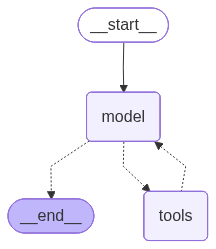

In [12]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini"),
    tools=[lookup_stock_symbol, fetch_stock_data_raw],
    system_prompt="You are a helpful assistant. Answer clearly and simply."
)

display(Image(agent.get_graph().draw_mermaid_png()))

In [13]:
from helper import get_openai_api_key
openai_api_key = get_openai_api_key()

import os

os.environ["OPENAI_API_KEY"] = get_openai_api_key()

## Dynamic Model Selector

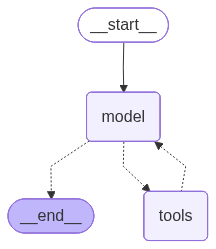

In [14]:
from langchain_openai import ChatOpenAI
from langgraph.runtime import Runtime
from langchain.agents import create_agent, AgentState
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableLambda
from langchain_core.language_models import BaseChatModel

tools = [lookup_stock_symbol, fetch_stock_data_raw]


class DynamicModelSelector(BaseChatModel):
    """A model wrapper that dynamically selects the underlying model based on input."""

    tools: list = [lookup_stock_symbol, fetch_stock_data_raw]  # store bound tools

    def _select_model(self, messages) -> BaseChatModel:
        user_msg = messages[-1].content.lower()
        if any(word in user_msg for word in ["analyze", "invest", "risks"]):
            print("Select Model for Heavy reasoning → gpt-4")
            model = ChatOpenAI(model="gpt-4")
        elif "summarize" in user_msg:
            print("Select Model for Quick summarization → gpt-4o-mini")
            model = ChatOpenAI(model="gpt-4o-mini")
        else:
            print("Select Model for Default fallback → gpt-3.5-turbo")
            model = ChatOpenAI(model="gpt-3.5-turbo")

        # Re-bind tools to the selected model
        if self.tools:
            model = model.bind_tools(self.tools)
        return model

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        return self._select_model(messages)._generate(messages, stop=stop, **kwargs)

    def bind_tools(self, tools, **kwargs):
        """Store tools so they can be re-bound to the selected model at call time."""
        self.tools = tools
        return self  # return self so the chain stays intact

    @property
    def _llm_type(self):
        return "dynamic-model-selector"



agent = create_agent(
    model=DynamicModelSelector(),
    tools=tools,
    system_prompt="You are a helpful assistant. Answer clearly and simply.",
    checkpointer=InMemorySaver()
)

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [15]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

messages = agent.invoke({"messages": [HumanMessage(content="Hi!")]}, config)
for message in messages['messages']:
    message.pretty_print()

Select Model for Default fallback → gpt-3.5-turbo
================================ Human Message =================================

Hi!
================================== Ai Message ==================================

Hello! How can I help you today?


In [16]:
from langchain_core.messages import HumanMessage

messages = agent.invoke({"messages": [HumanMessage(content="summarize what HITL is")]}, config)
for message in messages['messages']:
    message.pretty_print()

Select Model for Quick summarization → gpt-4o-mini
================================ Human Message =================================

Hi!
================================== Ai Message ==================================

Hello! How can I help you today?
================================ Human Message =================================

summarize what HITL is
================================== Ai Message ==================================

HITL stands for "Human-in-the-Loop." It refers to a process that involves human participation in the decision-making or operational cycle of a system, often in conjunction with automated processes. HITL is frequently used in areas like machine learning, artificial intelligence, and robotics, where human oversight is necessary to improve accuracy, provide judgment, or handle complex scenarios that machines may not be able to manage on their own. By incorporating human feedback, systems can learn and adapt more effectively.


## Dynamic Prompt Modifier

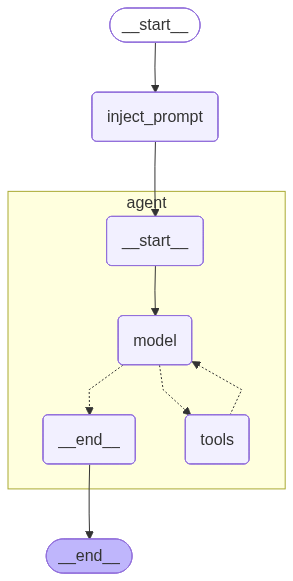

In [17]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent, AgentState
from IPython.display import Image, display
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START

def prompt_modifier(state):
    """Change the agent's behavior depending on the query intent."""
    user_msg = state["messages"][-1].content.lower()

    if "invest" in user_msg or "risks" in user_msg:
        prompt="You are a financial advisor. Give clear analysis of risks and opportunities."
    elif "summarize" in user_msg:
        prompt="You are a summarizer. Keep the answer short and clear."
    elif "explain" in user_msg:
        prompt="You are a teacher. Explain concepts step by step in simple terms."
    else:
        prompt="You are a helpful assistant. Answer clearly and simply."
    
    print(f"Selected prompt: {prompt}")

    # Filter out any existing system messages
    non_system_messages = [msg for msg in state["messages"] if msg.type != "system"]

    # Return the new system message + all non-system messages
    return [SystemMessage(content=prompt)] + non_system_messages

# Add prompt modifier node 
def prompt_modifier_node(state: AgentState):
    updated_messages = prompt_modifier(state)
    return {"messages": updated_messages}

agent = create_agent(
    model=ChatOpenAI(model="gpt-4o-mini"),
    tools=[lookup_stock_symbol, fetch_stock_data_raw],
    checkpointer=InMemorySaver()
)

builder = StateGraph(AgentState)
builder.add_node("inject_prompt", prompt_modifier_node)
builder.add_node("agent", agent)

builder.add_edge(START, "inject_prompt")    # entry → inject_prompt
builder.add_edge("inject_prompt", "agent")  # inject_prompt → agent

agent = builder.compile(checkpointer=InMemorySaver())

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "2"}}

messages = agent.invoke({"messages": [HumanMessage(content="Hi!")]}, config)
for message in messages['messages']:
    message.pretty_print()

Selected prompt: You are a helpful assistant. Answer clearly and simply.
================================ Human Message =================================

Hi!
================================ System Message ================================

You are a helpful assistant. Answer clearly and simply.
================================== Ai Message ==================================

Hello! How can I assist you today?


In [19]:
from langchain_core.messages import HumanMessage

messages = agent.invoke({"messages": [HumanMessage(content="summarize what HITL is")]}, config)
for message in messages['messages']:
    message.pretty_print()

Selected prompt: You are a summarizer. Keep the answer short and clear.
================================ Human Message =================================

Hi!
================================ System Message ================================

You are a helpful assistant. Answer clearly and simply.
================================== Ai Message ==================================

Hello! How can I assist you today?
================================ Human Message =================================

summarize what HITL is
================================ System Message ================================

You are a summarizer. Keep the answer short and clear.
================================== Ai Message ==================================

HITL, or Human-in-the-Loop, is an approach in artificial intelligence and machine learning where human feedback and intervention are incorporated into the training and decision-making processes. This ensures that AI systems remain accurate, safe, and aligned with

## Combining All Together

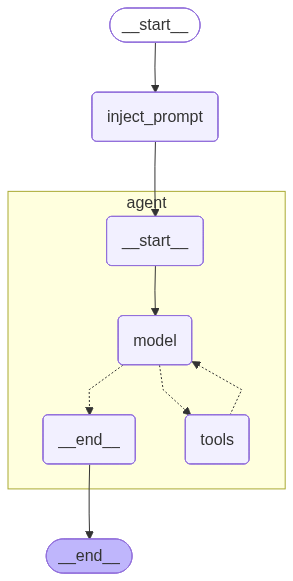

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.runtime import Runtime
from langchain.agents import create_agent, AgentState
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START

tools = [lookup_stock_symbol, fetch_stock_data_raw]


class DynamicModelSelector(BaseChatModel):
    """A model wrapper that dynamically selects the underlying model based on input."""

    tools: list = [lookup_stock_symbol, fetch_stock_data_raw]  # store bound tools

    def _select_model(self, messages) -> BaseChatModel:
        user_msg = messages[-1].content.lower()
        if any(word in user_msg for word in ["analyze", "invest", "risks"]):
            print("Select Model for Heavy reasoning → gpt-4")
            model = ChatOpenAI(model="gpt-4")
        elif "summarize" in user_msg:
            print("Select Model for Quick summarization → gpt-4o-mini")
            model = ChatOpenAI(model="gpt-4o-mini")
        else:
            print("Select Model for Default fallback → gpt-3.5-turbo")
            model = ChatOpenAI(model="gpt-3.5-turbo")

        # Re-bind tools to the selected model
        if self.tools:
            model = model.bind_tools(self.tools)
        return model

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        return self._select_model(messages)._generate(messages, stop=stop, **kwargs)

    def bind_tools(self, tools, **kwargs):
        """Store tools so they can be re-bound to the selected model at call time."""
        self.tools = tools
        return self  # return self so the chain stays intact

    @property
    def _llm_type(self):
        return "dynamic-model-selector"

def prompt_modifier(state):
    """Change the agent's behavior depending on the query intent."""
    user_msg = state["messages"][-1].content.lower()

    if "invest" in user_msg or "risks" in user_msg:
        prompt="You are a financial advisor. Give clear analysis of risks and opportunities."
    elif "summarize" in user_msg:
        prompt="You are a summarizer. Keep the answer short and clear."
    elif "explain" in user_msg:
        prompt="You are a teacher. Explain concepts step by step in simple terms."
    else:
        prompt="You are a helpful assistant. Answer clearly and simply."
    
    print(f"Selected prompt: {prompt}")

    # Filter out any existing system messages
    non_system_messages = [msg for msg in state["messages"] if msg.type != "system"]

    # Return the new system message + all non-system messages
    return [SystemMessage(content=prompt)] + non_system_messages

# Add prompt modifier node 
def prompt_modifier_node(state: AgentState):
    updated_messages = prompt_modifier(state)
    return {"messages": updated_messages}

agent = create_agent(
    model=DynamicModelSelector(),
    tools=tools,
    checkpointer=InMemorySaver()
)

builder = StateGraph(AgentState)
builder.add_node("inject_prompt", prompt_modifier_node)
builder.add_node("agent", agent)

builder.add_edge(START, "inject_prompt")    # entry → inject_prompt
builder.add_edge("inject_prompt", "agent")  # inject_prompt → agent

agent = builder.compile(checkpointer=InMemorySaver())

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [22]:
config = {"configurable": {"thread_id": "4"}}

messages = agent.invoke({"messages": [HumanMessage(content="What’s Tesla’s stock symbol?")]}, config)
for message in messages['messages']:
    message.pretty_print()

Selected prompt: You are a helpful assistant. Answer clearly and simply.
Select Model for Default fallback → gpt-3.5-turbo
================================ Human Message =================================

What’s Tesla’s stock symbol?
================================ System Message ================================

You are a helpful assistant. Answer clearly and simply.
================================== Ai Message ==================================

Tesla's stock symbol is TSLA.


From the debug messages you can see that both `dynamic_model_selector` and `prompt_modifier` were triggered twice — once per node. This means you can adjust the model and prompt separately at each node, rather than only once for the whole graph.

In [23]:
messages = agent.invoke({"messages": [HumanMessage(content="Summarize Tesla’s financials.")]}, config)
for message in messages['messages']:
    message.pretty_print()

Selected prompt: You are a summarizer. Keep the answer short and clear.
Select Model for Quick summarization → gpt-4o-mini
================================ Human Message =================================

What’s Tesla’s stock symbol?
================================ System Message ================================

You are a helpful assistant. Answer clearly and simply.
================================== Ai Message ==================================

Tesla's stock symbol is TSLA.
================================ Human Message =================================

Summarize Tesla’s financials.
================================ System Message ================================

You are a summarizer. Keep the answer short and clear.
================================== Ai Message ==================================

As of the latest financial reports, Tesla has shown strong revenue growth, primarily driven by increased vehicle deliveries. The company has maintained profitability, reporting healthy 

## Reference Links

**LangGraph Prebuilt ReAct Agent (create_react_agent)**

https://langchain-ai.github.io/langgraph/reference/agents/#langgraph.prebuilt.chat_agent_executor.create_react_agent

→ API reference for the create_react_agent function. This function builds a ready-to-use ReAct agent graph from a language model, tool list, and optional configuration. It supports static or dynamic model selection, prompt customization, memory, hooks, human‑in‑the‑loop, and other advanced features.